In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

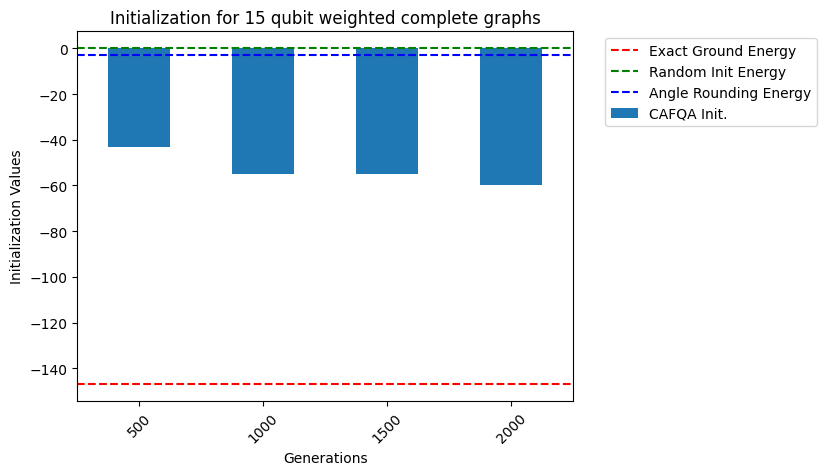

In [2]:
# create a dataframe with sample data
df = pd.DataFrame({
    'Generations': [500,1000,1500,2000],
    'CAFQA Init.': [-43,-55,-55,-60]
})

df.plot(x='Generations', y=['CAFQA Init.'], kind='bar')
exact_ground_energy = -147
random_init_energy = 0.09
angle_rounding_energy = -3

plt.axhline(y=exact_ground_energy, color='r', linestyle='--', label='Exact Ground Energy')
plt.axhline(y=random_init_energy, color='g', linestyle='--', label='Random Init Energy')
plt.axhline(y=angle_rounding_energy, color='b', linestyle='--', label='Angle Rounding Energy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('Generations')
plt.ylabel('Initialization Values')
plt.xticks(rotation=45)
plt.title('Initialization for 15 qubit weighted complete graphs')
plt.show()


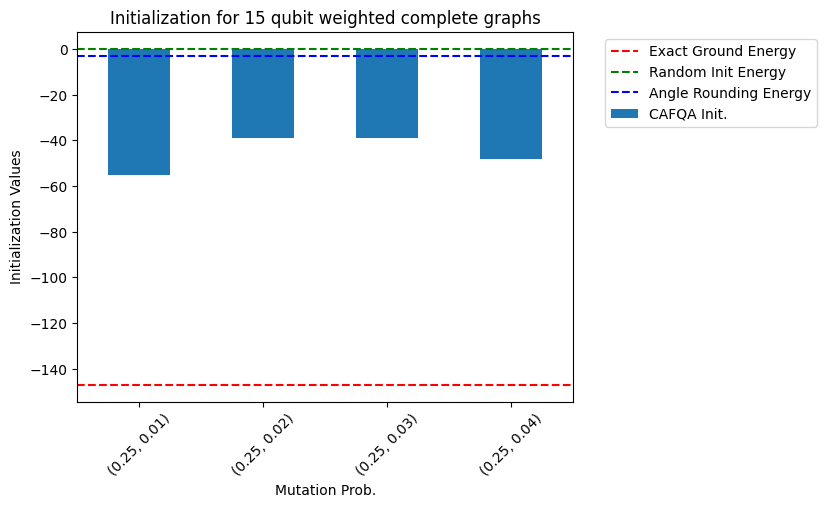

In [3]:
# create a dataframe with sample data
df = pd.DataFrame({
    'Mutation Prob.': [(0.25,0.01),(0.25,0.02),(0.25,0.03),(0.25,0.04)],
    'CAFQA Init.': [-55,-39,-39,-48]
})

df.plot(x='Mutation Prob.', y=['CAFQA Init.'], kind='bar')
exact_ground_energy = -147
random_init_energy = 0.09
angle_rounding_energy = -3

plt.axhline(y=exact_ground_energy, color='r', linestyle='--', label='Exact Ground Energy')
plt.axhline(y=random_init_energy, color='g', linestyle='--', label='Random Init Energy')
plt.axhline(y=angle_rounding_energy, color='b', linestyle='--', label='Angle Rounding Energy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('Mutation Prob.')
plt.ylabel('Initialization Values')
plt.xticks(rotation=45)
plt.title('Initialization for 15 qubit weighted complete graphs')
plt.show()


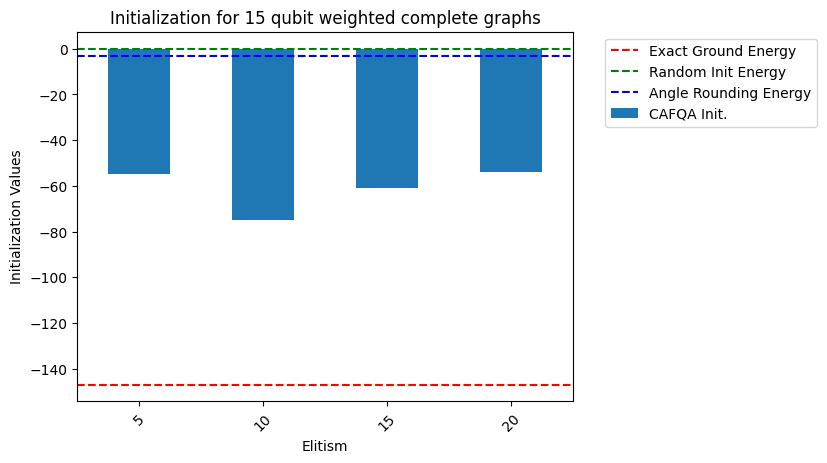

In [4]:
# create a dataframe with sample data
df = pd.DataFrame({
    'Elitism': [5,10,15,20],
    'CAFQA Init.': [-55,-75,-61,-54]
})

df.plot(x='Elitism', y=['CAFQA Init.'], kind='bar')
exact_ground_energy = -147
random_init_energy = 0.09
angle_rounding_energy = -3

plt.axhline(y=exact_ground_energy, color='r', linestyle='--', label='Exact Ground Energy')
plt.axhline(y=random_init_energy, color='g', linestyle='--', label='Random Init Energy')
plt.axhline(y=angle_rounding_energy, color='b', linestyle='--', label='Angle Rounding Energy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('Elitism')
plt.ylabel('Initialization Values')
plt.xticks(rotation=45)
plt.title('Initialization for 15 qubit weighted complete graphs')
plt.show()

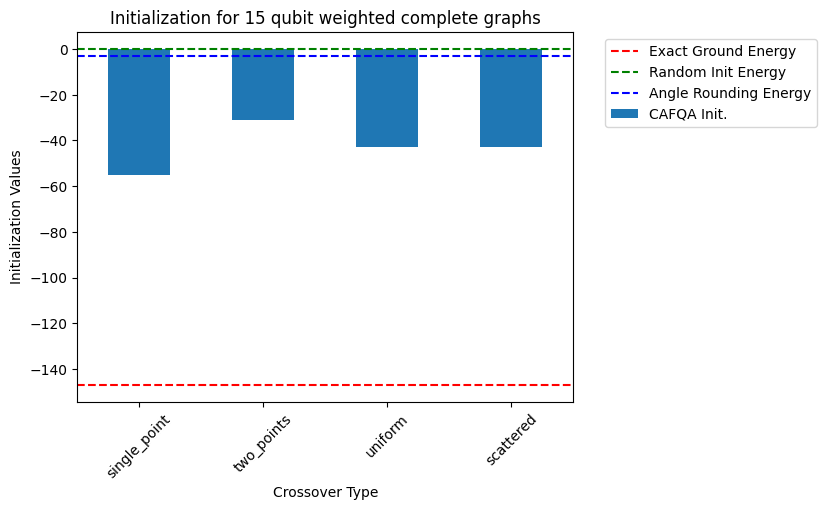

In [5]:
# create a dataframe with sample data
df = pd.DataFrame({
    'Elitism': ["single_point","two_points", "uniform", "scattered"],
    'CAFQA Init.': [-55,-31,-43,-43]
})

df.plot(x='Elitism', y=['CAFQA Init.'], kind='bar')
exact_ground_energy = -147
random_init_energy = 0.09
angle_rounding_energy = -3

plt.axhline(y=exact_ground_energy, color='r', linestyle='--', label='Exact Ground Energy')
plt.axhline(y=random_init_energy, color='g', linestyle='--', label='Random Init Energy')
plt.axhline(y=angle_rounding_energy, color='b', linestyle='--', label='Angle Rounding Energy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('Crossover Type')
plt.ylabel('Initialization Values')
plt.title('Initialization for 15 qubit weighted complete graphs')
plt.xticks(rotation=45)
plt.show()

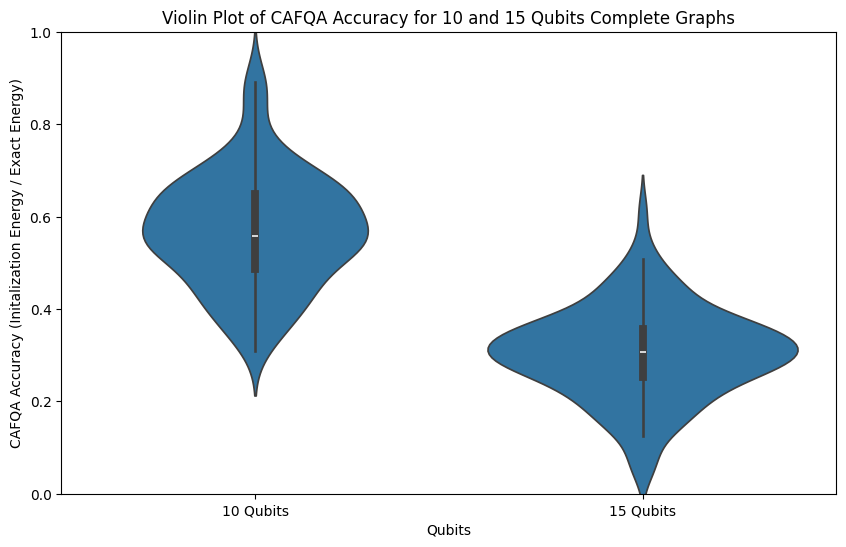

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def load_data(qubits, file_pattern, num_files):
    data_list = []
    for i in range(1, num_files + 1):
        file_path = file_pattern.format(i)
        data = np.load(file_path, allow_pickle=True).item()
        data['Qubits'] = f'{qubits} Qubits'
        data['CAFQA_Accuracy'] = data['CAFQA_initialization'] / data['Exact_solution']
        data['Random_Accuracy'] = data['Random_initialization'] / data['Exact_solution']
        data['Angle_Rounding_Accuracy'] = data['Angle_rounding'] / data['Exact_solution']
        data_list.append(data)
    return pd.DataFrame(data_list)

# Load data for 10 and 15 qubits
df_10 = load_data(10, '../np_data/10_qbs/energies_{}.npz.npy', 100)
df_15 = load_data(15, '../np_data/15_qbs/energies_{}.npy', 100)

# Combine the dataframes
df_combined = pd.concat([df_10, df_15])

# Plot the violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='Qubits', y='CAFQA_Accuracy', data=df_combined)
plt.title('Violin Plot of CAFQA Accuracy for 10 and 15 Qubits Complete Graphs')
plt.ylabel('CAFQA Accuracy (Initalization Energy / Exact Energy)')
plt.ylim(0, 1)
plt.show()

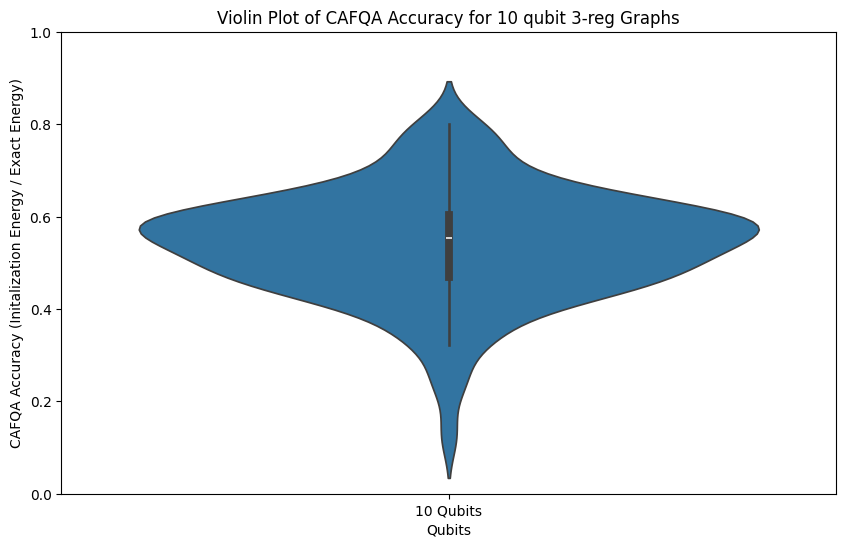

In [16]:


df_10_k_reg = load_data(10, '../np_data/10_qbs/k_reg_energies_{}.npy', 100)

plt.figure(figsize=(10, 6))
sns.violinplot(x='Qubits',y='CAFQA_Accuracy',data=df_10_k_reg)
plt.title('Violin Plot of CAFQA Accuracy for 10 qubit 3-reg Graphs')
plt.ylabel('CAFQA Accuracy (Initalization Energy / Exact Energy)')
plt.ylim(0, 1)
plt.show()


In [19]:
df_10['CAFQA_initialization'].mean(),df_15['CAFQA_initialization'].mean()

(np.float64(-43.71), np.float64(-43.01))